# 11 — acadosとReceding Horizon

OCPを1回解く処理と、先頭入力だけ使って解き直す閉ループを理解します。

**前提**: `10_mpc_objective_and_weights.ipynb`

> 読み方: 「直感 → 数式 → 上流コード → 小実験 → 解釈」の順です。
> `実装事実` と書いた箇所は現行 `external/Quadruped-PyMPC` のコード、
> `学習用モデル` は理解のために単純化した再実装です。

In [1]:
from pathlib import Path
import os, sys

ROOT = Path.cwd().resolve()
if ROOT.name == "notebook_pympc":
    ROOT = ROOT.parent
PYMPC_ROOT = ROOT / "external" / "Quadruped-PyMPC"
assert PYMPC_ROOT.exists(), f"Quadruped-PyMPC が見つかりません: {PYMPC_ROOT}"
if str(PYMPC_ROOT) not in sys.path:
    sys.path.insert(0, str(PYMPC_ROOT))

os.environ.setdefault("ACADOS_SOURCE_DIR", str(PYMPC_ROOT / "quadruped_pympc" / "acados"))
os.environ.setdefault("MUJOCO_GL", "egl")
print("workspace :", ROOT)
print("PyMPC root:", PYMPC_ROOT)

workspace : /home/takuya/work/mpc_dog
PyMPC root: /home/takuya/work/mpc_dog/external/Quadruped-PyMPC


## Receding horizon

時刻 \(t\) で \(u_0^\*,\ldots,u_{N-1}^\*\) を求めても、適用するのは原則 \(u_0^\*\) だけです。

\[
x_t\rightarrow\operatorname{solve}\rightarrow u_0^\*
\rightarrow x_{t+1}\rightarrow\operatorname{solve}\rightarrow\cdots
\]

PyMPCでは各stageへ `yref`、contact、摩擦、慣性、質量等を設定し、
`solve()` 後にstage 0の `u` を取得します。

In [2]:
# 学習用1次元MPC。上流acadosの「全horizonを解いて先頭だけ使う」を同型化。
import numpy as np
from scipy.optimize import minimize

def solve_scalar_mpc(x0, target, N=8, q=10., r=1.):
    # 力学制約 x[k+1]=x[k]+u[k] をrolloutとして消去する。
    def rollout(u):
        return x0 + np.concatenate([[0.], np.cumsum(u)])

    # J=sum q*(x-x_ref)^2 + r*u^2。上流のLINEAR_LS costに対応。
    def cost(u):
        x_prediction = rollout(u)
        return q*np.sum((x_prediction-target)**2) + r*np.sum(u**2)

    # |u|<=0.4が入力制約。実PyMPCではGRF・摩擦・foothold制約になる。
    result = minimize(cost, np.zeros(N), bounds=[(-.4,.4)]*N)
    return result.x, rollout(result.x), result.fun

x = -2.0
history = [x]
applied = []
for _ in range(12):
    # 毎周期、現在の観測xを初期条件としてN段を再最適化する。
    u_star, prediction, objective = solve_scalar_mpc(x, target=1.0)
    u = u_star[0]  # receding horizon: u*[0]だけPlantへ適用
    x = x + u      # 新しい観測を得たら残りu*[1:]は捨てて解き直す
    applied.append(u); history.append(x)
print("states :", np.round(history, 3))
print("inputs :", np.round(applied, 3))

states : [-2.    -1.6   -1.2   -0.8   -0.4   -0.     0.4    0.8    0.983  0.999
  1.     1.     1.   ]
inputs : [0.4   0.4   0.4   0.4   0.4   0.4   0.4   0.183 0.015 0.001 0.    0.   ]


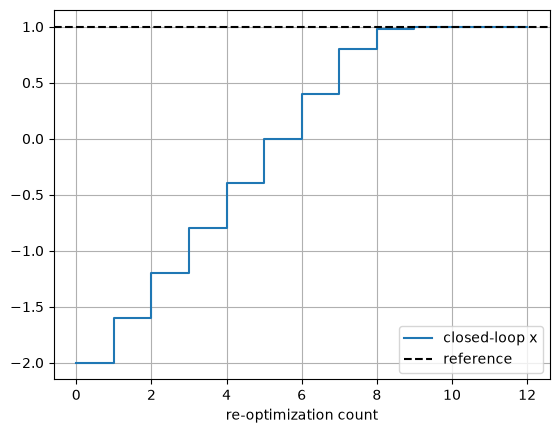

In [3]:
import matplotlib.pyplot as plt
plt.step(range(len(history)), history, where="post", label="closed-loop x")
plt.axhline(1.0, color="k", ls="--", label="reference")
plt.xlabel("re-optimization count"); plt.grid(); plt.legend(); plt.show()

`use_RTI=False` の標準はSQP、`num_qp_iterations=1` です。
1回の反復でも前回解・短周期再最適化により動作しますが、solver statusと計算時間を
必ず記録します。status異常時に最後の入力を無条件使用する設計は別途安全検討が必要です。

## 章末チェック

出力を眺めるだけでなく、次を自分の言葉で答えてください。

1. この章の入力・出力の shape、単位、座標系は何か。
2. 変更可能な量と、他の章から渡される量は何か。
3. パラメータを2倍にしたとき、どのグラフがどちらへ変化するか。
4. 現行実装の事実と、学習用の近似を区別できるか。